In [24]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.linear_model import RANSACRegressor, LinearRegression
import math

# Загрузка данных из файлов
def load_data(file_path):
    # Загрузим файл и извлечем нужные колонки
    data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
    return data[["X", "Y"]]

# Чтение данных из всех файлов
base_data = load_data("BASE.GK")
rover1_data = load_data("ROVER1.GK")
rover2_data = load_data("ROVER2.GK")

# Объединение данных (для одной стороны сквера можно выбрать, например, данные из BASE.GK)
data = base_data

data = data[(data['X'] >= 1.0625768e+01 ) & (data['X'] <= 9.9716747e+01) & (data['Y'] >= 1.0465813e+01) & (data['Y'] <= 9.2189232e+01)]

# Метод наименьших квадратов (МНК)
def linear_regression_lsq(X, Y):
    model = LinearRegression().fit(X.reshape(-1, 1), Y)
    a1 = model.coef_[0]
    a0 = model.intercept_
    return a1, a0

# Метод наименьших модулей (МНМ)
def linear_regression_lad(X, Y):
    def lad_loss(params):
        a1, a0 = params
        return np.sum(np.abs(Y - (a1 * X + a0)))

    # Инициализация параметров
    initial_params = [0, np.mean(Y)]
    result = minimize(lad_loss, initial_params, method='BFGS')
    a1, a0 = result.x
    return a1, a0

# Робастный метод (РНК) - RANSAC
def linear_regression_robust(X, Y, residual_threshold=5.0):
    model = RANSACRegressor(residual_threshold=residual_threshold).fit(X.reshape(-1, 1), Y)
    a1 = model.estimator_.coef_[0]
    a0 = model.estimator_.intercept_
    return a1, a0

# Применение методов
X = data["X"].values
Y = data["Y"].values

# МНК
a1_lsq, a0_lsq = linear_regression_lsq(X, Y)

# МНМ
a1_lad, a0_lad = linear_regression_lad(X, Y)

# РНК
a1_rnk, a0_rnk = linear_regression_robust(X, Y, residual_threshold=1.0)

# Функция для перевода коэффициента наклона в углы (градусы)
def slope_to_angle(slope):
    angle_rad = math.atan(slope)
    angle_deg = math.degrees(angle_rad)
    return angle_deg

# Вычисление углов наклона
angle_lsq = slope_to_angle(a1_lsq)
angle_lad = slope_to_angle(a1_lad)
angle_rnk = slope_to_angle(a1_rnk)

# Вывод результатов
print(f"Угол наклона (МНК): {angle_lsq:.6f}°")
print(f"Угол наклона (МНМ): {angle_lad:.6f}°")
print(f"Угол наклона (РНК): {angle_rnk:.6f}°")

# Сравнение наклонов в угловых мерах
difference_lsq_lad = abs(angle_lsq - angle_lad) * 60  # в угловых минутах
difference_lsq_rnk = abs(angle_lsq - angle_rnk) * 60  # в угловых минутах
difference_lad_rnk = abs(angle_lad - angle_rnk) * 60  # в угловых минутах

print(f"\nРазница в наклонах (МНК - МНМ): {difference_lsq_lad:.6f} минут")
print(f"Разница в наклонах (МНК - РНК): {difference_lsq_rnk:.6f} минут")
print(f"Разница в наклонах (МНМ - РНК): {difference_lad_rnk:.6f} минут")

Угол наклона (МНК): 43.851515°
Угол наклона (МНМ): 43.902214°
Угол наклона (РНК): 43.703650°

Разница в наклонах (МНК - МНМ): 3.041910 минут
Разница в наклонах (МНК - РНК): 8.871921 минут
Разница в наклонах (МНМ - РНК): 11.913831 минут


<ipython-input-24-3b88940b8f26>:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
<ipython-input-24-3b88940b8f26>:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
<ipython-input-24-3b88940b8f26>:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])


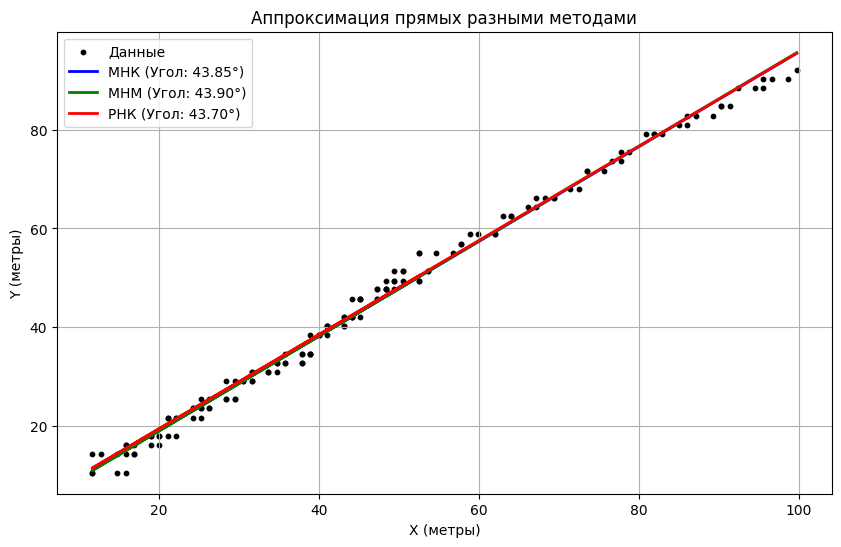

In [25]:
import matplotlib.pyplot as plt

# Функция для построения графиков
def plot_regression_lines(X, Y, a1_lsq, a0_lsq, a1_lad, a0_lad, a1_rnk, a0_rnk):
    plt.figure(figsize=(10, 6))
    plt.scatter(X, Y, color='black', label='Данные', s=10)

    # Построение линии для МНК
    Y_pred_lsq = a1_lsq * X + a0_lsq
    plt.plot(X, Y_pred_lsq, color='blue', label=f'МНК (Угол: {slope_to_angle(a1_lsq):.2f}°)', linewidth=2)

    # Построение линии для МНМ
    Y_pred_lad = a1_lad * X + a0_lad
    plt.plot(X, Y_pred_lad, color='green', label=f'МНМ (Угол: {slope_to_angle(a1_lad):.2f}°)', linewidth=2)

    # Построение линии для РНК
    Y_pred_rnk = a1_rnk * X + a0_rnk
    plt.plot(X, Y_pred_rnk, color='red', label=f'РНК (Угол: {slope_to_angle(a1_rnk):.2f}°)', linewidth=2)

    # Настройки графика
    plt.xlabel("X (метры)")
    plt.ylabel("Y (метры)")
    plt.title("Аппроксимация прямых разными методами")
    plt.legend()
    plt.grid(True)
    plt.show()

# Построение графика
plot_regression_lines(X, Y, a1_lsq, a0_lsq, a1_lad, a0_lad, a1_rnk, a0_rnk)

In [26]:
import numpy as np
import pandas as pd

# Загрузка данных из файлов
def load_data(file_path):
    # Загрузим файл и извлечем нужные колонки
    data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
    return data[["X", "Y"]]

# Чтение данных из всех файлов
base_data = load_data("BASE.GK")
rover1_data = load_data("ROVER1.GK")
rover2_data = load_data("ROVER2.GK")

# Определяем эталонные координаты (среднее значение из BASE.GK)
base_x_mean = base_data["X"].mean()
base_y_mean = base_data["Y"].mean()

# Погрешности для Rover1
rover1_errors_x = rover1_data["X"] - base_x_mean
rover1_errors_y = rover1_data["Y"] - base_y_mean
rover1_errors = np.sqrt(rover1_errors_x**2 + rover1_errors_y**2)  # Общая погрешность (евклидова)

# Погрешности для Rover2
rover2_errors_x = rover2_data["X"] - base_x_mean
rover2_errors_y = rover2_data["Y"] - base_y_mean
rover2_errors = np.sqrt(rover2_errors_x**2 + rover2_errors_y**2)  # Общая погрешность (евклидова)

# Расчет дисперсии погрешностей
variance_rover1 = np.var(rover1_errors)
variance_rover2 = np.var(rover2_errors)

# Вывод результатов
print(f"Дисперсия погрешностей Rover1: {variance_rover1:.6f}")
print(f"Дисперсия погрешностей Rover2: {variance_rover2:.6f}")

Дисперсия погрешностей Rover1: 1854.346271
Дисперсия погрешностей Rover2: 1869.826887


<ipython-input-26-a455ac503e46>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
<ipython-input-26-a455ac503e46>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
<ipython-input-26-a455ac503e46>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])


In [27]:
import numpy as np
import pandas as pd

# Загрузка данных из файлов
def load_data(file_path):
    # Загрузим файл и извлечем нужные колонки
    data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
    return data[["X", "Y"]]

# Чтение данных из всех файлов
base_data = load_data("BASE.GK")
rover1_data = load_data("ROVER1.GK")
rover2_data = load_data("ROVER2.GK")

# Определяем эталонные координаты (среднее значение из BASE.GK)
base_x_mean = base_data["X"].mean()
base_y_mean = base_data["Y"].mean()

# Погрешности для Rover1 относительно BASE
rover1_errors_x = rover1_data["X"] - base_x_mean
rover1_errors_y = rover1_data["Y"] - base_y_mean
rover1_errors = np.sqrt(rover1_errors_x**2 + rover1_errors_y**2)  # Общая погрешность (евклидова)

# Погрешности для Rover2 относительно BASE
rover2_errors_x = rover2_data["X"] - base_x_mean
rover2_errors_y = rover2_data["Y"] - base_y_mean
rover2_errors = np.sqrt(rover2_errors_x**2 + rover2_errors_y**2)  # Общая погрешность (евклидова)

# Дифференциальная обработка: разница между Rover1 и Rover2
diff_x = rover1_data["X"] - rover2_data["X"]
diff_y = rover1_data["Y"] - rover2_data["Y"]
diff_errors = np.sqrt(diff_x**2 + diff_y**2)  # Погрешность разности

# Оценка влияния атмосферы: среднее значение погрешностей
mean_diff_error = np.mean(diff_errors)

# Вывод результатов
print(f"Средняя погрешность для Rover1 относительно BASE: {np.mean(rover1_errors):.6f} метров")
print(f"Средняя погрешность для Rover2 относительно BASE: {np.mean(rover2_errors):.6f} метров")
print(f"Средняя погрешность для дифференциальной обработки (Rover1 - Rover2): {mean_diff_error:.6f} метров")

Средняя погрешность для Rover1 относительно BASE: 101.389947 метров
Средняя погрешность для Rover2 относительно BASE: 71.765834 метров
Средняя погрешность для дифференциальной обработки (Rover1 - Rover2): 61.235507 метров


<ipython-input-27-eb6a69b6e5f8>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
<ipython-input-27-eb6a69b6e5f8>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
<ipython-input-27-eb6a69b6e5f8>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, names=["Time", "X", "Y", "Z"])
